![H-1B Visa](https://images.techhive.com/images/article/2016/12/h-1b-visa9-100698034-large.jpg)

# What is H-1B VISA?

* H-1B visas are a category of employment-based, non-immigrant visas for temporary foreign workers in the United States. For a foreign national to apply for H1-B visa, a US employer must offer them a job and submit a petition for a H-1B visa to the US immigration department. This is also the most common visa status applied for and held by international students once they complete college or higher education and begin working in a full-time position.

# Content

This dataset contains five year's worth of H-1B petition data, with approximately 3 million records overall. The columns in the dataset include case status, employer name, worksite coordinates, job title, prevailing wage, occupation code, and year filed.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.pyplot import plot

tableau20 = [(31, 119, 180), (174, 199, 232), (255, 127, 14), (255, 187, 120),    
             (44, 160, 44), (152, 223, 138), (214, 39, 40), (255, 152, 150),    
             (148, 103, 189), (197, 176, 213), (140, 86, 75), (196, 156, 148),    
             (227, 119, 194), (247, 182, 210), (127, 127, 127), (199, 199, 199),    
             (188, 189, 34), (219, 219, 141), (23, 190, 207), (158, 218, 229)]  

for i in range(len(tableau20)):    
    r, g, b = tableau20[i]    
    tableau20[i] = (r / 255., g / 255., b / 255.) 

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/h-1b-visa/h1b_kaggle.csv


In [2]:
df = pd.read_csv('/kaggle/input/h-1b-visa/h1b_kaggle.csv')

In [3]:
#  Memory saving function credit to https://www.kaggle.com/gemartin/load-data-reduce-memory-usage
def reduce_mem_usage(df):
    """ iterate through all the columns of a dataframe and modify the data type
        to reduce memory usage.        
    """
    #start_mem = df.memory_usage().sum() / 1024**2
    #print('Memory usage of dataframe is {:.2f} MB'.format(start_mem))

    for col in df.columns:
        col_type = df[col].dtype

        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)

    #end_mem = df.memory_usage().sum() / 1024**2
    #print('Memory usage after optimization is: {:.2f} MB'.format(end_mem))
    #print('Decreased by {:.1f}%'.format(100 * (start_mem - end_mem) / start_mem))

    return df

## The meaning of the columns are as follows:

* **CASE_STATUS** - status of the application
* **EMPLOYER_NAME** - the name of the employer as registered in the H-1B Visa application
* **SOC_NAME** - the occupation code for the employment
* **JOB_TITLE** - the job title for the employment
* **FULL_TIME_POSITION** - whether the application is for a full-time position of for a part-time position
* **PREVAILING_WAGE** - the most frequent wage for the corresponding role as filled in the Visa application
* **YEAR** - the application year
* **WORKSITE** - the address of the employer worksite
* **lon** - longitude of the employer worksite
* **lat** - latitude of the employer worksite

In [4]:
df = reduce_mem_usage(df)
df.head()

,Unnamed: 0,CASE_STATUS,EMPLOYER_NAME,SOC_NAME,JOB_TITLE,FULL_TIME_POSITION,PREVAILING_WAGE,YEAR,WORKSITE,lon,lat
0,1,CERTIFIED-WITHDRAWN,UNIVERSITY OF MICHIGAN,BIOCHEMISTS AND BIOPHYSICISTS,POSTDOCTORAL RESEARCH FELLOW,N,36067.00000,2016.0,"ANN ARBOR, MICHIGAN",-83.7500,42.28125
1,2,CERTIFIED-WITHDRAWN,"GOODMAN NETWORKS, INC.",CHIEF EXECUTIVES,CHIEF OPERATING OFFICER,Y,242674.00000,2016.0,"PLANO, TEXAS",-96.6875,33.03125
2,3,CERTIFIED-WITHDRAWN,"PORTS AMERICA GROUP, INC.",CHIEF EXECUTIVES,CHIEF PROCESS OFFICER,Y,193066.00000,2016.0,"JERSEY CITY, NEW JERSEY",-74.0625,40.71875
3,4,CERTIFIED-WITHDRAWN,"GATES CORPORATION, A WHOLLY-OWNED SUBSIDIARY O...",CHIEF EXECUTIVES,"REGIONAL PRESIDEN, AMERICAS",Y,220314.00000,2016.0,"DENVER, COLORADO",-105.0000,39.75000
4,5,WITHDRAWN,PEABODY INVESTMENTS CORP.,CHIEF EXECUTIVES,PRESIDENT MONGOLIA AND INDIA,Y,157518.40625,2016.0,"ST. LOUIS, MISSOURI",-90.1875,38.62500


In [5]:
df.describe()

,Unnamed: 0,PREVAILING_WAGE,YEAR,lon,lat
count,3.002458e+06,3.002373e+06,3002445.0,2.895216e+06,2.895216e+06
mean,1.501230e+06,1.472152e+05,NaN,NaN,NaN
std,8.667351e+05,5.286995e+06,NaN,0.000000e+00,0.000000e+00
min,1.000000e+00,0.000000e+00,2011.0,-1.578750e+02,1.343750e+01
25%,7.506152e+05,5.437100e+04,2012.0,-1.119375e+02,3.415625e+01
50%,1.501230e+06,6.502100e+04,2014.0,-8.618750e+01,3.909375e+01
75%,2.251844e+06,8.143200e+04,2015.0,-7.550000e+01,4.087500e+01
max,3.002458e+06,6.997607e+09,2016.0,1.457500e+02,6.481250e+01


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3002458 entries, 0 to 3002457
Data columns (total 11 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Unnamed: 0          int32  
 1   CASE_STATUS         object 
 2   EMPLOYER_NAME       object 
 3   SOC_NAME            object 
 4   JOB_TITLE           object 
 5   FULL_TIME_POSITION  object 
 6   PREVAILING_WAGE     float32
 7   YEAR                float16
 8   WORKSITE            object 
 9   lon                 float16
 10  lat                 float16
dtypes: float16(3), float32(1), int32(1), object(6)
memory usage: 177.5+ MB


In [7]:
print("The shape of the dataset is : {}".format(df.shape))

The shape of the dataset is : (3002458, 11)


In [8]:
print("There were around {} applications for H-1B Visa from 2011 to 2016.".format(df.shape[0]))

There were around 3002458 applications for H-1B Visa from 2011 to 2016.


# 1. Exploratory Data Analysis (EDA).

In [9]:
df.CASE_STATUS.value_counts()

CERTIFIED                                             2615623
CERTIFIED-WITHDRAWN                                    202659
DENIED                                                  94346
WITHDRAWN                                               89799
PENDING QUALITY AND COMPLIANCE REVIEW - UNASSIGNED         15
REJECTED                                                    2
INVALIDATED                                                 1
Name: CASE_STATUS, dtype: int64

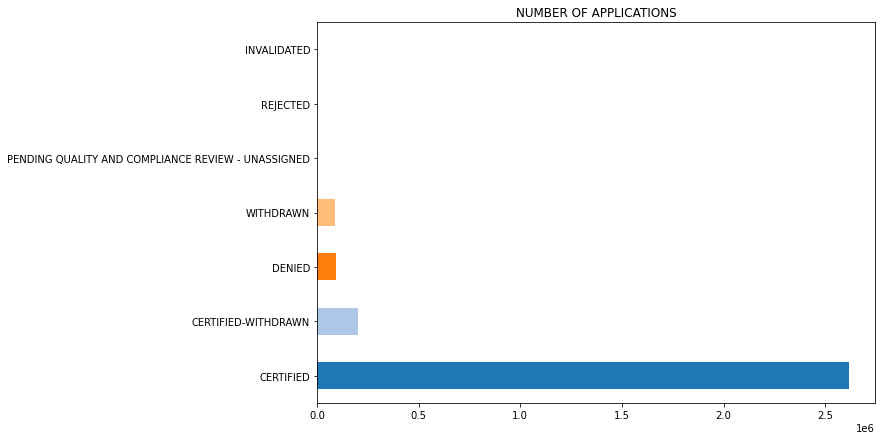

In [10]:
plt.figure(figsize=(10,7))
df.CASE_STATUS.value_counts().plot(kind='barh',  color=tableau20)
df.sort_values('CASE_STATUS')
plt.title("NUMBER OF APPLICATIONS")
plt.show()

* From the above graph we can say that the employees who have applied for the **H-1B Visa** were more than **2500000** whose application got **certified** and there were more than 200000 whose application's were **certified and withdrawn** and there were around **90000** whose application's were **denied** and there we around **80000** were **withdrawn**

### NUmber of Applications per year

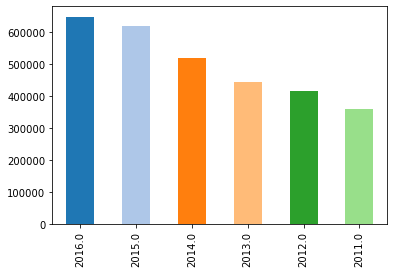

In [11]:
df.YEAR.value_counts().plot(kind = 'bar',color=tableau20)

* We can that there is an exponential increase in the number of applications as the year passes

In [12]:
df.columns

Index(['Unnamed: 0', 'CASE_STATUS', 'EMPLOYER_NAME', 'SOC_NAME', 'JOB_TITLE',
       'FULL_TIME_POSITION', 'PREVAILING_WAGE', 'YEAR', 'WORKSITE', 'lon',
       'lat'],
      dtype='object')

### TOp 10 applicants in 2011

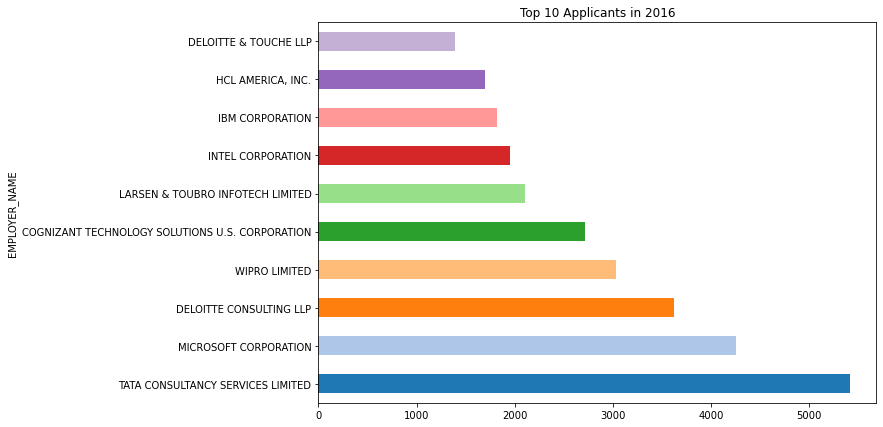

In [13]:
plt.figure(figsize=(10,7))

ax1 = df['EMPLOYER_NAME'][df['YEAR'] == 2011].groupby(df['EMPLOYER_NAME']).count().sort_values(ascending=False).head(10).plot(kind='barh', title = "Top 10 Applicants in 2016",
                                                                                                                           color=tableau20)
ax1.set_label("")
plt.show()

## Top 10 Applicants in 2016

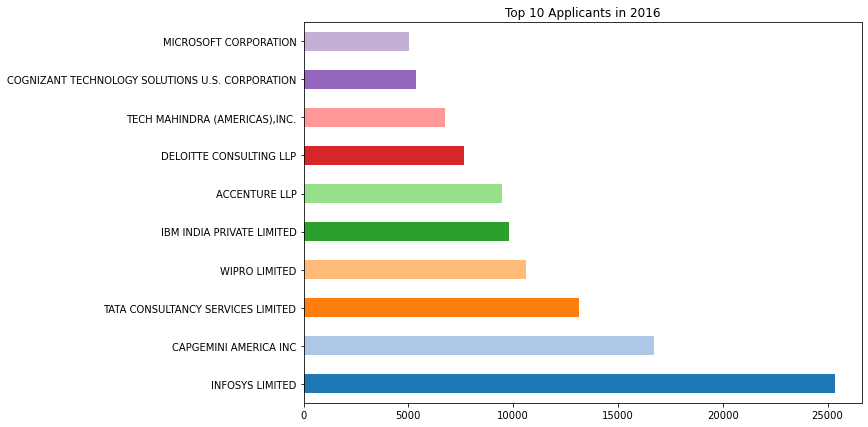

In [14]:
plt.figure(figsize=(10,7))

ax2 = df['EMPLOYER_NAME'][df['YEAR'] == 2016].groupby(df['EMPLOYER_NAME']).count().sort_values(ascending=False).head(10).plot(kind='barh', title='Top 10 Applicants in 2016'
                                                                                                                             ,color=tableau20)
ax2.set_ylabel("")
plt.show()

## Top 10 Applicants from 2011 to 2016

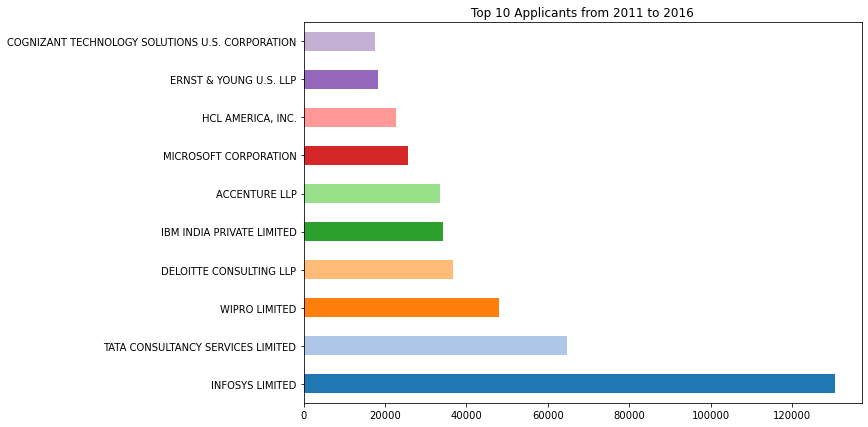

In [15]:
plt.figure(figsize=(10,7))

ax3 = df['EMPLOYER_NAME'].groupby([df['EMPLOYER_NAME']]).count().sort_values(ascending=False).head(10).plot(kind = 'barh', title = 'Top 10 Applicants from 2011 to 2016'
                                                                                                           ,color=tableau20)
ax3.set_ylabel("")
plt.show()

### Analyzing more number of top 10 employees 

In [16]:
top_emp = list(df['EMPLOYER_NAME'][df['YEAR'] >= 2015].groupby(df['EMPLOYER_NAME']).count().sort_values(ascending=False).head(10).index)

byempyear = df[['EMPLOYER_NAME', 'YEAR', 'PREVAILING_WAGE']][df['EMPLOYER_NAME'].isin(top_emp)]

byempyear = byempyear.groupby([df['EMPLOYER_NAME'], df['YEAR']])

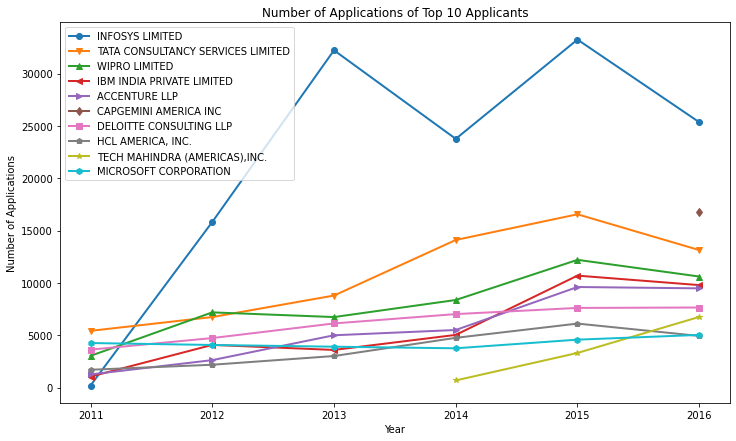

In [17]:
plt.figure(figsize=(12,7))

markers=['o','v','^','<','>','d','s','p','*','h','x','D','o','v','^','<','>','d','s','p','*','h','x','D']

for company in top_emp:
    tmp = byempyear.count().loc[company]
    plt.plot(tmp.index.values, tmp["PREVAILING_WAGE"].values, label=company, linewidth=2,marker=markers[top_emp.index(company)])
plt.xlabel("Year")
plt.ylabel("Number of Applications")
plt.legend()
plt.title('Number of Applications of Top 10 Applicants')
plt.show()

* We can clearly see that there are 2 new companies which are **TECH MAHINDRA (AMERICAS),INC.** & **CAPGEMINI AMERICA**.
* **INFOSYS** showed rapid growth between the year 2011 and 2013 where it came from 0 applications to more than 30k applications.
* **TATA** also showed a significant growth.
* From the above plot except the 2 new comers we can say that the number of applications receving to the top 10 employer started decreasing from the year 2015. 
* All very top applications are from India.
* These are the companies who filed the most number of applicaions.

### Let's check the average salary of each company 

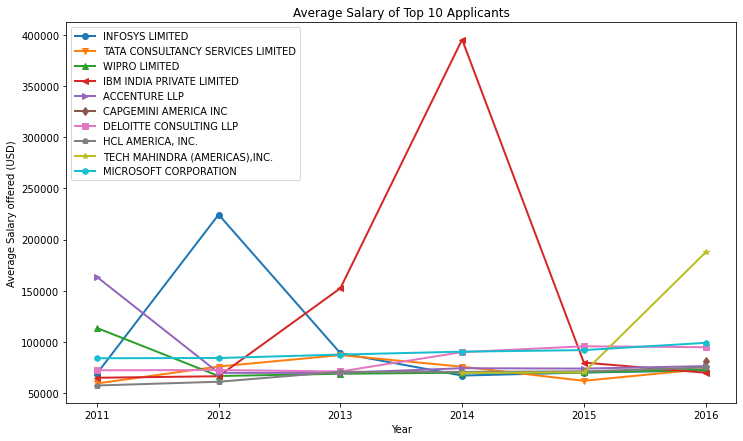

In [18]:
plt.figure(figsize=(12,7))

for company in top_emp:
    tmp = byempyear.mean().loc[company]
    plt.plot(tmp.index.values, tmp["PREVAILING_WAGE"].values, label=company, linewidth=2,marker=markers[top_emp.index(company)])
plt.xlabel("Year")
plt.ylabel("Average Salary offered (USD)")
plt.legend()
plt.title('Average Salary of Top 10 Applicants')
plt.show()

* We can see that the Average Salary offered by **Infosys** was very high as compared to rest of the companies in the year 2012.
* It's very interesting to see a huge peak in 2014 by **IBM INDIA PRIVATE LIMITED** looking like something went wrong.
* More sudden peak's were observed by **ACCENTURE LLP** in year **2011** and by **TECH MAHINDRA** in the year 2016.
* Now we need to further analyze the peaks.

In [19]:
df.head()

,Unnamed: 0,CASE_STATUS,EMPLOYER_NAME,SOC_NAME,JOB_TITLE,FULL_TIME_POSITION,PREVAILING_WAGE,YEAR,WORKSITE,lon,lat
0,1,CERTIFIED-WITHDRAWN,UNIVERSITY OF MICHIGAN,BIOCHEMISTS AND BIOPHYSICISTS,POSTDOCTORAL RESEARCH FELLOW,N,36067.00000,2016.0,"ANN ARBOR, MICHIGAN",-83.7500,42.28125
1,2,CERTIFIED-WITHDRAWN,"GOODMAN NETWORKS, INC.",CHIEF EXECUTIVES,CHIEF OPERATING OFFICER,Y,242674.00000,2016.0,"PLANO, TEXAS",-96.6875,33.03125
2,3,CERTIFIED-WITHDRAWN,"PORTS AMERICA GROUP, INC.",CHIEF EXECUTIVES,CHIEF PROCESS OFFICER,Y,193066.00000,2016.0,"JERSEY CITY, NEW JERSEY",-74.0625,40.71875
3,4,CERTIFIED-WITHDRAWN,"GATES CORPORATION, A WHOLLY-OWNED SUBSIDIARY O...",CHIEF EXECUTIVES,"REGIONAL PRESIDEN, AMERICAS",Y,220314.00000,2016.0,"DENVER, COLORADO",-105.0000,39.75000
4,5,WITHDRAWN,PEABODY INVESTMENTS CORP.,CHIEF EXECUTIVES,PRESIDENT MONGOLIA AND INDIA,Y,157518.40625,2016.0,"ST. LOUIS, MISSOURI",-90.1875,38.62500


## TOp job titles according to 2016.

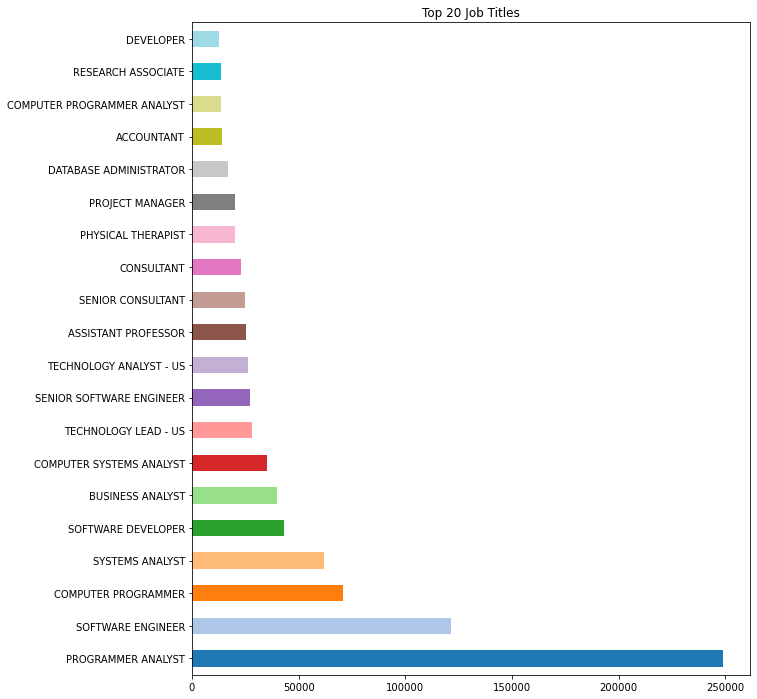

In [20]:
plt.figure(figsize=(10,12))
df.JOB_TITLE.value_counts().nlargest(20).plot(kind = 'barh', title = "Top 20 Job Titles",color=tableau20)
plt.show()

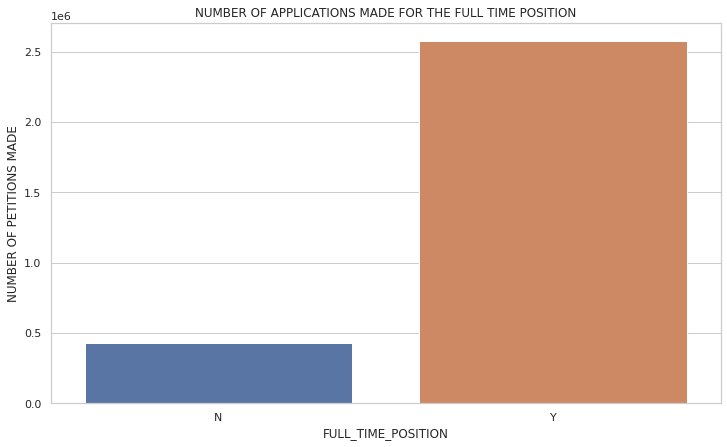

In [21]:
plt.figure(figsize=(12,7))
sns.set(style="whitegrid")
g = sns.countplot(x = 'FULL_TIME_POSITION', data = df)
plt.title("NUMBER OF APPLICATIONS MADE FOR THE FULL TIME POSITION")
plt.ylabel("NUMBER OF PETITIONS MADE")
plt.show()

* From the countplot we can see that around 85% of the total jobs are full time.

# 2. Feature Engineering

In [22]:
df.head()

,Unnamed: 0,CASE_STATUS,EMPLOYER_NAME,SOC_NAME,JOB_TITLE,FULL_TIME_POSITION,PREVAILING_WAGE,YEAR,WORKSITE,lon,lat
0,1,CERTIFIED-WITHDRAWN,UNIVERSITY OF MICHIGAN,BIOCHEMISTS AND BIOPHYSICISTS,POSTDOCTORAL RESEARCH FELLOW,N,36067.00000,2016.0,"ANN ARBOR, MICHIGAN",-83.7500,42.28125
1,2,CERTIFIED-WITHDRAWN,"GOODMAN NETWORKS, INC.",CHIEF EXECUTIVES,CHIEF OPERATING OFFICER,Y,242674.00000,2016.0,"PLANO, TEXAS",-96.6875,33.03125
2,3,CERTIFIED-WITHDRAWN,"PORTS AMERICA GROUP, INC.",CHIEF EXECUTIVES,CHIEF PROCESS OFFICER,Y,193066.00000,2016.0,"JERSEY CITY, NEW JERSEY",-74.0625,40.71875
3,4,CERTIFIED-WITHDRAWN,"GATES CORPORATION, A WHOLLY-OWNED SUBSIDIARY O...",CHIEF EXECUTIVES,"REGIONAL PRESIDEN, AMERICAS",Y,220314.00000,2016.0,"DENVER, COLORADO",-105.0000,39.75000
4,5,WITHDRAWN,PEABODY INVESTMENTS CORP.,CHIEF EXECUTIVES,PRESIDENT MONGOLIA AND INDIA,Y,157518.40625,2016.0,"ST. LOUIS, MISSOURI",-90.1875,38.62500


### Removing the outliers from the dataset.

In [23]:
df = df[df['PREVAILING_WAGE'] <= 500000]
by_emp_year = df[['EMPLOYER_NAME', 'YEAR', 'PREVAILING_WAGE']][df['EMPLOYER_NAME'].isin(top_emp)]
by_emp_year = by_emp_year.groupby([df['EMPLOYER_NAME'],df['YEAR']])

In [24]:
df.PREVAILING_WAGE.max()

499417.0

(target)case_Status, full_time_pos, prewaling wage, year

## Label enconding the CASE_STATUS feature

* What is **Label Encoding** ?
     - **Label Encoding** refers to converting the labels into numeric form so as to convert it into the machine-readable form. Machine learning algorithms can then decide in a better way on how those labels must be operated. It is an important pre-processing step for the structured dataset in supervised learning.

In [25]:
## Checking for null values
df.isnull().sum()

Unnamed: 0                 0
CASE_STATUS                0
EMPLOYER_NAME             42
SOC_NAME               17698
JOB_TITLE                 26
FULL_TIME_POSITION         0
PREVAILING_WAGE            0
YEAR                       0
WORKSITE                   0
lon                   107089
lat                   107089
dtype: int64

In [26]:
df['SOC_NAME'] = df['SOC_NAME'].fillna(df['SOC_NAME'].mode()[0])

In [27]:
df.CASE_STATUS.value_counts()

CERTIFIED                                             2615530
CERTIFIED-WITHDRAWN                                    202650
DENIED                                                  92149
WITHDRAWN                                               89565
PENDING QUALITY AND COMPLIANCE REVIEW - UNASSIGNED         15
REJECTED                                                    2
INVALIDATED                                                 1
Name: CASE_STATUS, dtype: int64

In [28]:
df['CASE_STATUS'] = df['CASE_STATUS'].map({'CERTIFIED' : 0, 'CERTIFIED-WITHDRAWN' : 1, 'DENIED' : 2, 'WITHDRAWN' : 3, 
                                           'PENDING QUALITY AND COMPLIANCE REVIEW - UNASSIGNED' : 4, 'REJECTED' : 5, 'INVALIDATED' : 6})

In [29]:
df.head()

,Unnamed: 0,CASE_STATUS,EMPLOYER_NAME,SOC_NAME,JOB_TITLE,FULL_TIME_POSITION,PREVAILING_WAGE,YEAR,WORKSITE,lon,lat
0,1,1,UNIVERSITY OF MICHIGAN,BIOCHEMISTS AND BIOPHYSICISTS,POSTDOCTORAL RESEARCH FELLOW,N,36067.00000,2016.0,"ANN ARBOR, MICHIGAN",-83.7500,42.28125
1,2,1,"GOODMAN NETWORKS, INC.",CHIEF EXECUTIVES,CHIEF OPERATING OFFICER,Y,242674.00000,2016.0,"PLANO, TEXAS",-96.6875,33.03125
2,3,1,"PORTS AMERICA GROUP, INC.",CHIEF EXECUTIVES,CHIEF PROCESS OFFICER,Y,193066.00000,2016.0,"JERSEY CITY, NEW JERSEY",-74.0625,40.71875
3,4,1,"GATES CORPORATION, A WHOLLY-OWNED SUBSIDIARY O...",CHIEF EXECUTIVES,"REGIONAL PRESIDEN, AMERICAS",Y,220314.00000,2016.0,"DENVER, COLORADO",-105.0000,39.75000
4,5,3,PEABODY INVESTMENTS CORP.,CHIEF EXECUTIVES,PRESIDENT MONGOLIA AND INDIA,Y,157518.40625,2016.0,"ST. LOUIS, MISSOURI",-90.1875,38.62500


* Similarly performing the same operation with `FULL_TIME_POSITION` feature.

In [30]:
df.FULL_TIME_POSITION.value_counts()

Y    2573666
N     426246
Name: FULL_TIME_POSITION, dtype: int64

 * For the `FULL_TIME_POSITION` the variable indicates that the application is whether for Y : full-time position and N : part-time position.

In [31]:
df['FULL_TIME_POSITION'] = df['FULL_TIME_POSITION'].map({'N' : 0, 'Y' : 1})
df.head()

,Unnamed: 0,CASE_STATUS,EMPLOYER_NAME,SOC_NAME,JOB_TITLE,FULL_TIME_POSITION,PREVAILING_WAGE,YEAR,WORKSITE,lon,lat
0,1,1,UNIVERSITY OF MICHIGAN,BIOCHEMISTS AND BIOPHYSICISTS,POSTDOCTORAL RESEARCH FELLOW,0,36067.00000,2016.0,"ANN ARBOR, MICHIGAN",-83.7500,42.28125
1,2,1,"GOODMAN NETWORKS, INC.",CHIEF EXECUTIVES,CHIEF OPERATING OFFICER,1,242674.00000,2016.0,"PLANO, TEXAS",-96.6875,33.03125
2,3,1,"PORTS AMERICA GROUP, INC.",CHIEF EXECUTIVES,CHIEF PROCESS OFFICER,1,193066.00000,2016.0,"JERSEY CITY, NEW JERSEY",-74.0625,40.71875
3,4,1,"GATES CORPORATION, A WHOLLY-OWNED SUBSIDIARY O...",CHIEF EXECUTIVES,"REGIONAL PRESIDEN, AMERICAS",1,220314.00000,2016.0,"DENVER, COLORADO",-105.0000,39.75000
4,5,3,PEABODY INVESTMENTS CORP.,CHIEF EXECUTIVES,PRESIDENT MONGOLIA AND INDIA,1,157518.40625,2016.0,"ST. LOUIS, MISSOURI",-90.1875,38.62500


In [32]:
df['SOC_NAME'].value_counts()

Computer Systems Analysts                   308564
Computer Programmers                        226272
SOFTWARE DEVELOPERS, APPLICATIONS           221745
COMPUTER SYSTEMS ANALYSTS                   215315
Software Developers, Applications           192692
                                             ...  
NETWORK SECURITY ANALYSTS                        1
<FONT><FONT>CARPINTEROS</FONT></FONT>            1
DATA ENTRY KEYERS                                1
HEALTH SPECIALTY TEACHERS, POSTSECONDARY         1
COMPUTER OCCUPATIONS, OTHER                      1
Name: SOC_NAME, Length: 2130, dtype: int64

In [33]:
import sys
df['SOC_NAME1'] = 'others'
df['SOC_NAME1'][df['SOC_NAME'].str.contains('computer','software')] = 'it'
df['SOC_NAME1'][df['SOC_NAME'].str.contains('chief','management')] = 'manager'
df['SOC_NAME1'][df['SOC_NAME'].str.contains('mechanical')] = 'mechanical'
df['SOC_NAME1'][df['SOC_NAME'].str.contains('database')] = 'database'
df['SOC_NAME1'][df['SOC_NAME'].str.contains('sales','market')] = 'scm'
df['SOC_NAME1'][df['SOC_NAME'].str.contains('financial')] = 'finance'
df['SOC_NAME1'][df['SOC_NAME'].str.contains('public','fundraising')] = 'pr'
df['SOC_NAME1'][df['SOC_NAME'].str.contains('education','law')] = 'administrative'
df['SOC_NAME1'][df['SOC_NAME'].str.contains('auditors','compliance')] = 'audit'
df['SOC_NAME1'][df['SOC_NAME'].str.contains('distribution','logistics')] = 'scm'
df['SOC_NAME1'][df['SOC_NAME'].str.contains('recruiters','human')] = 'hr'
df['SOC_NAME1'][df['SOC_NAME'].str.contains('agricultural','farm')] = 'agri'
df['SOC_NAME1'][df['SOC_NAME'].str.contains('construction','architectural')] = 'estate'
df['SOC_NAME1'][df['SOC_NAME'].str.contains('forencsic','health')] = 'medical'
df['SOC_NAME1'][df['SOC_NAME'].str.contains('teachers')] = 'education'

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until
/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.
/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-

In [34]:
df.head()

,Unnamed: 0,CASE_STATUS,EMPLOYER_NAME,SOC_NAME,JOB_TITLE,FULL_TIME_POSITION,PREVAILING_WAGE,YEAR,WORKSITE,lon,lat,SOC_NAME1
0,1,1,UNIVERSITY OF MICHIGAN,BIOCHEMISTS AND BIOPHYSICISTS,POSTDOCTORAL RESEARCH FELLOW,0,36067.00000,2016.0,"ANN ARBOR, MICHIGAN",-83.7500,42.28125,others
1,2,1,"GOODMAN NETWORKS, INC.",CHIEF EXECUTIVES,CHIEF OPERATING OFFICER,1,242674.00000,2016.0,"PLANO, TEXAS",-96.6875,33.03125,others
2,3,1,"PORTS AMERICA GROUP, INC.",CHIEF EXECUTIVES,CHIEF PROCESS OFFICER,1,193066.00000,2016.0,"JERSEY CITY, NEW JERSEY",-74.0625,40.71875,others
3,4,1,"GATES CORPORATION, A WHOLLY-OWNED SUBSIDIARY O...",CHIEF EXECUTIVES,"REGIONAL PRESIDEN, AMERICAS",1,220314.00000,2016.0,"DENVER, COLORADO",-105.0000,39.75000,others
4,5,3,PEABODY INVESTMENTS CORP.,CHIEF EXECUTIVES,PRESIDENT MONGOLIA AND INDIA,1,157518.40625,2016.0,"ST. LOUIS, MISSOURI",-90.1875,38.62500,others


* Dropping the unwanted columns from the dataset.

In [35]:
df.columns

Index(['Unnamed: 0', 'CASE_STATUS', 'EMPLOYER_NAME', 'SOC_NAME', 'JOB_TITLE',
       'FULL_TIME_POSITION', 'PREVAILING_WAGE', 'YEAR', 'WORKSITE', 'lon',
       'lat', 'SOC_NAME1'],
      dtype='object')

In [36]:
df = df.drop(['Unnamed: 0', 'EMPLOYER_NAME', 'SOC_NAME','JOB_TITLE','WORKSITE', 'lon','lat'], axis = 1)

In [37]:
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
le.fit(df.SOC_NAME1)
# print list(le.classes_)
df['SOC_N']=le.transform(df['SOC_NAME1'])

In [38]:
df.head()

,CASE_STATUS,FULL_TIME_POSITION,PREVAILING_WAGE,YEAR,SOC_NAME1,SOC_N
0,1,0,36067.00000,2016.0,others,2
1,1,1,242674.00000,2016.0,others,2
2,1,1,193066.00000,2016.0,others,2
3,1,1,220314.00000,2016.0,others,2
4,3,1,157518.40625,2016.0,others,2


In [39]:
df = df.drop(['SOC_NAME1'], axis=1)

# 3. Feature Selection.

**Feature Selection** is the process where you automatically or manually select those features which contribute most to your prediction variable or output in which you are interested in.

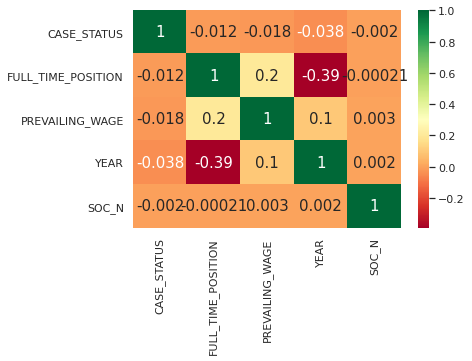

In [40]:
sns.heatmap(df.corr(), annot=True, cmap="RdYlGn", annot_kws={"size":15})

* Dividing the data into Independent and Dependent variables.

In [41]:
df.columns

Index(['CASE_STATUS', 'FULL_TIME_POSITION', 'PREVAILING_WAGE', 'YEAR',
       'SOC_N'],
      dtype='object')

In [42]:
x = df.drop(['CASE_STATUS'], axis=1) # Independent variables
y = df['CASE_STATUS'] # Dependent variables

In [43]:
x.columns

Index(['FULL_TIME_POSITION', 'PREVAILING_WAGE', 'YEAR', 'SOC_N'], dtype='object')

## Splitting the data into train test split

In [44]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)

# 4. Model Building 

In [45]:
from sklearn.preprocessing import OneHotEncoder
x_train_encode = pd.get_dummies(x_train)
x_test_encode = pd.get_dummies(x_test)

### Applying Logistic Regression Algorithm

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
LogReg = LogisticRegression()
LogReg.fit(x_train_encode, y_train)
y_pred = LogReg.predict(x_test_encode)

In [47]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

/opt/conda/lib/python3.7/site-packages/sklearn/metrics/_classification.py:1221: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

           0       0.87      1.00      0.93    784458
           1       0.00      0.00      0.00     60711
           2       0.00      0.00      0.00     27545
           3       0.00      0.00      0.00     27253
           4       0.00      0.00      0.00         6
           6       0.00      0.00      0.00         1

    accuracy                           0.87    899974
   macro avg       0.15      0.17      0.16    899974
weighted avg       0.76      0.87      0.81    899974



# If you like it please consider upvoting :)

In [ ]:
# Code to save the model (append to notebook after training)
import pickle

# Save the model
with open('visa_model.pkl', 'wb') as f:
    pickle.dump(LogReg, f)

# Save the LabelEncoders (assuming separate encoders for each categorical)
# If reusing 'le', save it, but better to use separate as below
le_job = LabelEncoder()
le_ftp = LabelEncoder()
x['JOB_TITLE'] = le_job.fit_transform(x['JOB_TITLE'])
x['FULL_TIME_POSITION'] = le_ftp.fit_transform(x['FULL_TIME_POSITION'])

with open('le_job.pkl', 'wb') as f:
    pickle.dump(le_job, f)
with open('le_ftp.pkl', 'wb') as f:
    pickle.dump(le_ftp, f)

print("Model and encoders saved.")